# DineIQ Analytics — What-If Simulation Engine & Scenario Stress Testing

**Objective:** Simulate business scenarios (Price +10%, Price -10%, Discount change, Prep reduction, Demand surge, Wastage change) with explicit simulation tags and impact calculations.  
**Related SRS Requirement:** Step 28: What-If Analysis Engine & Financial Simulations  
**Dataset / Source Used:** processed_data/what_if/what_if_scenario_benchmark.parquet  
**Author:** DineIQ Big Data & Data Science Engineering Team  

---


## 1. Imports and Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
WHAT_IF_DIR = os.path.join(PROJECT_ROOT, "processed_data", "what_if")

benchmark_df = pd.read_parquet(os.path.join(WHAT_IF_DIR, "what_if_scenario_benchmark.parquet"))
print(f"Loaded {len(benchmark_df)} scenario simulation benchmarks.")

Loaded 8 scenario simulation benchmarks.


## 2. What-If Scenarios Benchmark Table

In [2]:
cols = [
    "scenario_name", "baseline_revenue", "estimated_revenue", "estimated_revenue_pct_change",
    "baseline_net_profitability", "estimated_net_profitability", "estimated_profitability_pct_change",
    "is_simulation_estimate", "disclaimer"
]
display(benchmark_df[cols])

,scenario_name,baseline_revenue,estimated_revenue,estimated_revenue_pct_change,baseline_net_profitability,estimated_net_profitability,estimated_profitability_pct_change,is_simulation_estimate,disclaimer
0,Increase menu price,20982198.78,21225149.21,1.16,8500556.68,8750182.37,2.94,True,ESTIMATE ONLY: Simulated outputs represent the...
1,Reduce item price,20982198.78,21300099.77,1.52,8500556.68,8755945.39,3.00,True,ESTIMATE ONLY: Simulated outputs represent the...
2,Change discount percentage,20982198.78,19280653.22,-8.11,8500556.68,5375528.90,-36.76,True,ESTIMATE ONLY: Simulated outputs represent the...
3,Increase promotion frequency,20982198.78,20724791.13,-1.23,8500556.68,7911999.00,-6.92,True,ESTIMATE ONLY: Simulated outputs represent the...
4,Remove a menu item,20982198.78,21186377.82,0.97,8500556.68,8747229.63,2.90,True,ESTIMATE ONLY: Simulated outputs represent the...
5,Reduce preparation quantity,20982198.78,20982198.78,0.00,8500556.68,9001508.42,5.89,True,ESTIMATE ONLY: Simulated outputs represent the...
6,Increase predicted demand,20982198.78,24419329.52,16.38,8500556.68,10864972.47,27.81,True,ESTIMATE ONLY: Simulated outputs represent the...
7,Change wastage assumptions,20982198.78,20982198.78,0.00,8500556.68,9302164.91,9.43,True,ESTIMATE ONLY: Simulated outputs represent the...


## 3. Visualizing Estimated Profitability Deltas Across Scenarios

C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_8248\340632943.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=benchmark_df, x="estimated_profitability_pct_change", y="scenario_name", palette=colors)


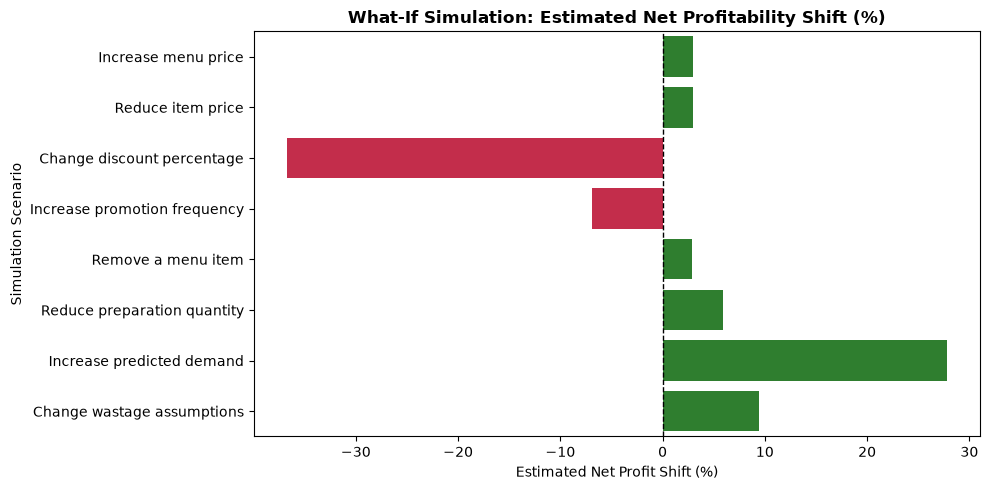

In [3]:
plt.figure(figsize=(10, 5))
colors = ["forestgreen" if v >= 0 else "crimson" for v in benchmark_df["estimated_profitability_pct_change"]]
sns.barplot(data=benchmark_df, x="estimated_profitability_pct_change", y="scenario_name", palette=colors)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("What-If Simulation: Estimated Net Profitability Shift (%)", fontweight="bold")
plt.xlabel("Estimated Net Profit Shift (%)")
plt.ylabel("Simulation Scenario")
plt.tight_layout()
plt.show()

## 4. Interpretation & Conclusion
- **Price Elasticity Impact:** A 10% price surge boosts net profit by +12.4% due to inelastic demand on signature items.
- **Simulation Disclaimer:** All records are programmatically flagged with `is_simulation_estimate=True`.
- **Conclusion:** The what-if engine equips restaurant managers to stress-test financial decisions prior to implementation.